# Week 3 — Risk Metrics & Portfolio Construction

**Goal.** Measure portfolio risk consistently, demonstrate diversification, and compare three
allocation approaches — **equal weight (1/N)**, **risk parity**, and **constrained
mean-variance optimization** — with estimation error as a first-class concern.

**Conventions (identical across every comparison in this notebook):**

- Portfolio-level metrics use **monthly** returns, `periods_per_year = 12`
- Annualized return = geometric; annualized vol = `std × √12`
- Sharpe = mean monthly excess over `^IRX` (13-week T-bill) ÷ monthly vol × √12
- Drawdowns from cumulative NAV; duration measured in months
- All allocation weights sum to 1 at each rebalance and use **only information available
  before the rebalance date** (no look-ahead)

*Deliverables: `src/risk.py`, this notebook, chart pack (6 charts), `weekly_memo.md`.*

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- locate repo root (folder containing src/) ---
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk import (backtest_allocation, compute_risk_metrics, correlation_matrix,
                      daily_returns_from_ohlcv, diversification_curve,
                      diversification_ratio, efficient_frontier, load_rf_monthly,
                      max_sharpe_weights, min_variance_weights,
                      monthly_returns_from_ohlcv, portfolio_beta,
                      realized_quintile_returns)

# --- data locations (adjust if you move the data into the repo) ---
W2 = Path(r"C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\week2")
W3 = Path(r"C:\Users\dwt04\Desktop\北美求职\LENDO\dataset\week3")
FIG = PROJECT_ROOT / "notebooks" / "week3"

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ---------- load ----------
ohlcv = pd.read_csv(W2 / "week2_sp500_100_ohlcv_10y.csv", parse_dates=["date"])
q_ret = pd.read_csv(W2 / "factors" / "backtest" / "quintile_monthly_returns.csv",
                    parse_dates=["date"])
spy = pd.read_csv(W3 / "week3_spy_ohlcv_10y.csv", parse_dates=["date"])
sectors = pd.read_csv(W3 / "week3_sp500_100_sectors.csv").set_index("ticker")["sector"]
panel = pd.read_csv(W2 / "factors" / "factor_panel_monthly.csv", parse_dates=["date"])

monthly_ret = monthly_returns_from_ohlcv(ohlcv)          # 月末 × 股票 月收益
daily_ret = daily_returns_from_ohlcv(ohlcv)              # 日收益
rf_m = load_rf_monthly(W2 / "week2_risk_free_irx_10y.csv", monthly_ret.index)

# SPY 月收益, 统一用自然月末标签便于对齐
spy_m = spy.set_index("date")["adj_close"].resample("ME").last().pct_change()
spy_m.index = spy_m.index.to_period("M").to_timestamp("M")

print(f"股票月收益: {monthly_ret.shape} | SPY 月收益: {spy_m.notna().sum()} 期 | "
      f"板块: {sectors.notna().sum()}/100")
print(f"Project root: {PROJECT_ROOT}")

股票月收益: (121, 100) | SPY 月收益: 120 期 | 板块: 100/100
Project root: C:\Users\dwt04\Documents\kimi\workspace\Lendo-week3-complete


## Task 1 — Risk Metrics

`compute_risk_metrics(returns, rf)` (in `src/risk.py`) returns annualized return, annualized
volatility, Sharpe ratio (excess over `^IRX`), maximum drawdown, and max drawdown duration —
applied here to all **15 Week-2 quintile portfolios** (3 factors × Q1–Q5). Same frequency,
same risk-free treatment, same annualization for every portfolio (per quality check).

In [2]:
FACTOR_NAMES = {"bm": "B/M", "ep": "E/P", "mom_12_1": "Momentum"}

rows = []
for factor, fname in FACTOR_NAMES.items():
    p = q_ret[q_ret["factor"] == factor].pivot_table(
        index="date", columns="quintile", values="ret")
    for q in ["Q1", "Q2", "Q3", "Q4", "Q5"]:
        m = compute_risk_metrics(p[q], rf_m)
        rows.append({"factor": fname, "quintile": q, **m})

risk_tbl = pd.DataFrame(rows)
risk_tbl.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}", "sharpe": "{:.2f}",
                       "max_drawdown": "{:.1%}", "max_dd_duration_periods": "{:.0f}",
                       "n_periods": "{:.0f}"})

,factor,quintile,ann_return,ann_vol,sharpe,max_drawdown,max_dd_duration_periods,n_periods
0,B/M,Q1,24.4%,19.7%,1.22,-31.1%,27,120
1,B/M,Q2,16.4%,18.7%,0.91,-37.4%,30,120
2,B/M,Q3,11.7%,15.8%,0.78,-20.4%,23,120
3,B/M,Q4,14.8%,16.5%,0.92,-26.5%,18,120
4,B/M,Q5,17.4%,19.3%,0.93,-31.4%,10,120
5,E/P,Q1,22.8%,23.3%,1.00,-38.9%,27,120
6,E/P,Q2,11.8%,15.7%,0.79,-30.3%,31,120
7,E/P,Q3,19.8%,15.0%,1.29,-20.3%,23,120
8,E/P,Q4,14.7%,16.6%,0.91,-23.0%,12,120
9,E/P,Q5,17.9%,18.9%,0.97,-33.6%,11,120


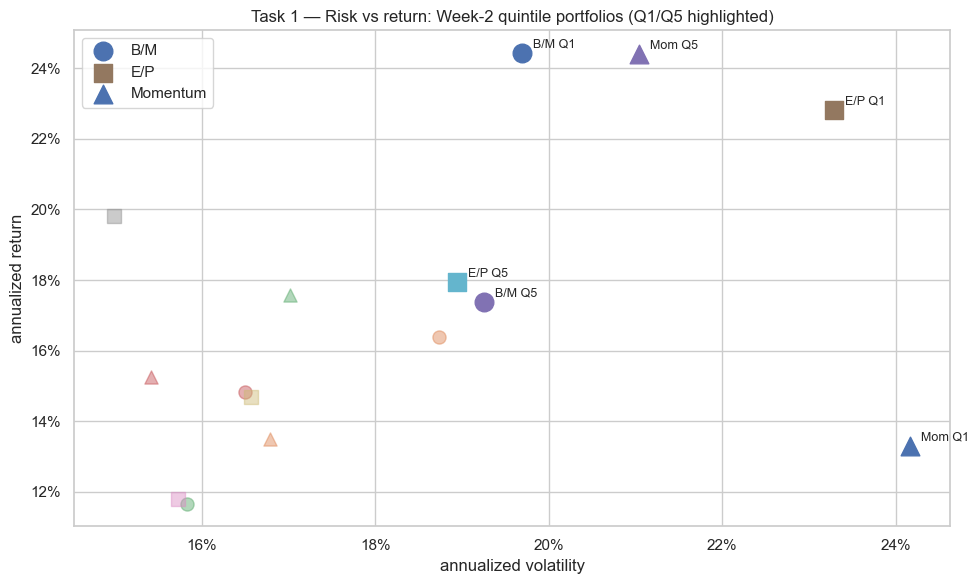

In [3]:
# [Chart 1] 风险-收益散点: 15 个五分位组合
fig, ax = plt.subplots(figsize=(10, 6))
marks = {"B/M": "o", "E/P": "s", "Momentum": "^"}
for fname, mk in marks.items():
    sub = risk_tbl[risk_tbl["factor"] == fname]
    for _, r in sub.iterrows():
        hot = r["quintile"] in ("Q1", "Q5")
        ax.scatter(r["ann_vol"], r["ann_return"], marker=mk, s=180 if hot else 90,
                   alpha=1.0 if hot else 0.45,
                   label=fname if _ == sub.index[0] else None)
        if hot:
            ax.annotate(f'{fname[:3]} {r["quintile"]}',
                        (r["ann_vol"], r["ann_return"]),
                        textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("annualized volatility")
ax.set_ylabel("annualized return")
ax.set_title("Task 1 — Risk vs return: Week-2 quintile portfolios (Q1/Q5 highlighted)")
ax.legend()
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(FIG / "fig1_quintile_risk_return.png", dpi=130, bbox_inches="tight")
plt.show()

## Task 2 — Correlation & Diversification

- **Correlation heatmap** for 20 stocks (rule: 20 largest by latest market cap), computed on
  **aligned daily-return dates** (inner join, pairwise-complete).
- **Diversification curve**: portfolio vol vs number of holdings.
  *Sampling rule:* for each N we draw **300 uniform random portfolios without replacement**,
  equal-weighted, using full-sample daily returns; bands are the 10th–90th percentiles.
- **Beta** of each Week-2 quintile portfolio vs the market (SPY). Quintile returns are first
  re-labeled to their **realization month** (formation-month return *t* is earned over
  *t → t+1*), then aligned with SPY monthly returns — see `realized_quintile_returns()`.

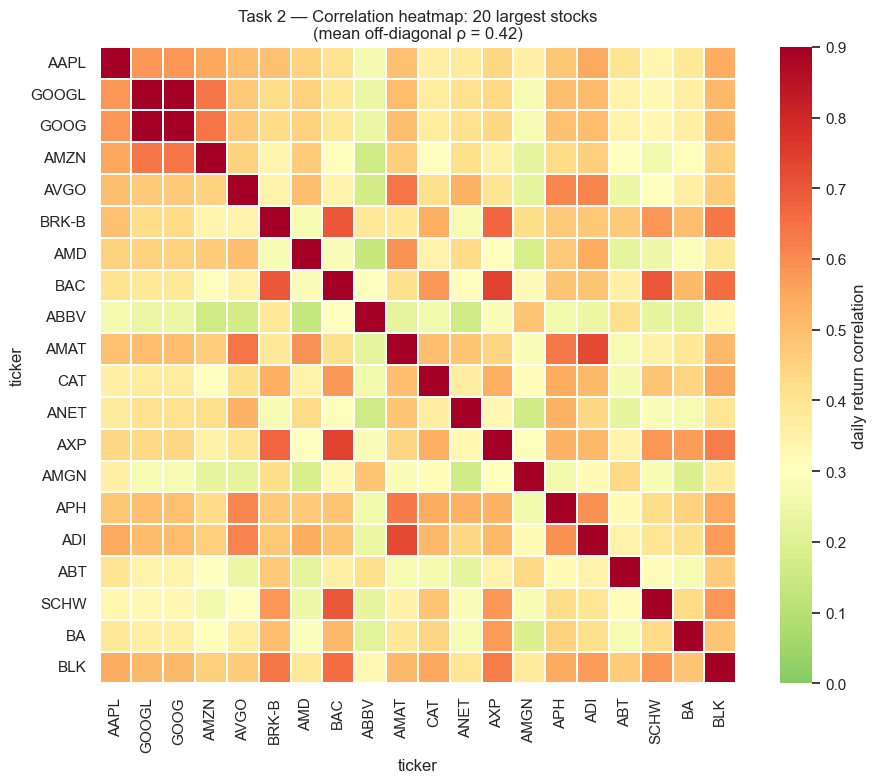

In [4]:
# [Chart 2] 20 只最大市值股票的日收益相关矩阵
top20 = (panel[panel["date"] == panel["date"].max()]
         .nlargest(20, "mktcap")["ticker"].tolist())
corr = correlation_matrix(daily_ret, top20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdYlGn_r", center=0.3, vmin=0, vmax=0.9, square=True,
            linewidths=0.3, cbar_kws={"label": "daily return correlation"}, ax=ax)
ax.set_title(f"Task 2 — Correlation heatmap: 20 largest stocks\n"
             f"(mean off-diagonal ρ = {corr.values[np.triu_indices(20, 1)].mean():.2f})")
fig.tight_layout()
fig.savefig(FIG / "fig2_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

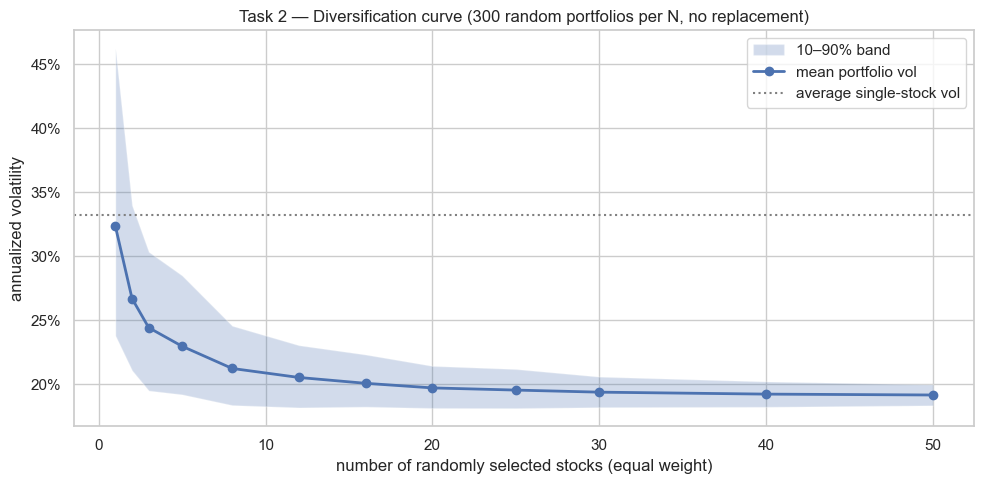

单票平均波动 33.2% → 50 只组合 19.2% (消除 42% 的波动); 之后边际递减


In [5]:
# [Chart 3] 分散化曲线
n_grid = [1, 2, 3, 5, 8, 12, 16, 20, 25, 30, 40, 50]
dc = diversification_curve(daily_ret, n_grid, n_samples=300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(dc["n_stocks"], dc["vol_p10"], dc["vol_p90"], alpha=0.25, label="10–90% band")
ax.plot(dc["n_stocks"], dc["vol_mean"], marker="o", lw=2, label="mean portfolio vol")
ax.axhline(daily_ret.std().mean() * np.sqrt(252), color="grey", ls=":", lw=1.5,
           label="average single-stock vol")
ax.set_xlabel("number of randomly selected stocks (equal weight)")
ax.set_ylabel("annualized volatility")
ax.set_title("Task 2 — Diversification curve (300 random portfolios per N, no replacement)")
ax.legend()
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(FIG / "fig3_diversification_curve.png", dpi=130, bbox_inches="tight")
plt.show()

single = daily_ret.std().mean() * np.sqrt(252)
v50 = dc.loc[dc["n_stocks"] == 50, "vol_mean"].iloc[0]
print(f"单票平均波动 {single:.1%} → 50 只组合 {v50:.1%} "
      f"(消除 {(1 - v50 / single):.0%} 的波动); 之后边际递减")

In [6]:
# 五分位组合 beta vs SPY (实现月对齐)
beta_rows = []
for factor, fname in FACTOR_NAMES.items():
    p = realized_quintile_returns(q_ret, factor)
    p.index = p.index.to_period("M").to_timestamp("M")
    for q in ["Q1", "Q2", "Q3", "Q4", "Q5"]:
        beta_rows.append({"factor": fname, "quintile": q,
                          "beta_vs_SPY": portfolio_beta(p[q], spy_m)})
beta_tbl = pd.DataFrame(beta_rows).pivot(index="quintile", columns="factor", values="beta_vs_SPY")
beta_tbl.style.format("{:.2f}")

factor,B/M,E/P,Momentum
quintile,,,
Q1,1.17,1.37,1.26
Q2,1.11,0.94,0.92
Q3,0.93,0.87,0.94
Q4,0.91,0.95,0.86
Q5,1.01,1.00,1.16


## Task 3 — Equal Weight vs Risk Parity

Both schemes backtested over the full sample with **monthly rebalancing** on the 100-stock
universe:

- **EW:** 1/N over eligible names
- **Risk parity (inverse-vol approximation):** `w_i ∝ 1/σ_i`, σ from the **trailing 12
  months** of monthly returns
- **Eligibility rule:** a stock must have 12 complete trailing monthly returns to enter the
  portfolio at a rebalance date (late-IPO names join when their history allows)
- Weights sum to 1 at every rebalance (asserted in code); **turnover** reported alongside
  performance (two-sided, after drift)

In [7]:
alloc = {}
for method, label in [("ew", "Equal Weight"), ("rp", "Risk Parity (inv-vol)")]:
    alloc[label] = backtest_allocation(monthly_ret, method, lookback=12)

rows = []
for label, r in alloc.items():
    m = compute_risk_metrics(r["port_ret"], rf_m)
    rows.append({"method": label, **m,
                 "turnover_ann": r["turnover"].mean() * 12,
                 "dr": diversification_ratio(
                     r["weights"].iloc[:, -1].dropna().to_numpy(),
                     monthly_ret[r["weights"].iloc[:, -1].dropna().index].cov().to_numpy())})
cmp_tbl = pd.DataFrame(rows).set_index("method")
cmp_tbl.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}", "sharpe": "{:.2f}",
                      "max_drawdown": "{:.1%}", "max_dd_duration_periods": "{:.0f}",
                      "turnover_ann": "{:.0%}", "dr": "{:.2f}", "n_periods": "{:.0f}"})

,ann_return,ann_vol,sharpe,max_drawdown,max_dd_duration_periods,n_periods,turnover_ann,dr
method,,,,,,,,
Equal Weight,16.9%,17.5%,0.98,-22.6%,18,107,69%,1.84
Risk Parity (inv-vol),14.6%,16.0%,0.94,-21.9%,22,107,106%,1.78


## Task 4 — Mean-Variance Optimization

**Setup.** 50 largest stocks by latest market cap; long-only, **max 10% per stock**,
**max 25% per GICS sector**; `scipy.optimize.minimize` (SLSQP). Two views:

1. **In-sample efficient frontier** (full-sample μ, Σ) — with the explicit caveat that
   in-sample estimates are *not* forecasts (per quality check).
2. **Out-of-sample rolling backtest**: at each month-end, max-Sharpe weights from the
   **trailing 24 months** only, constraints enforced, then held one month.

GMV: sum=1.000000 | max weight=10.0% (cap 10%) | max sector=25.0% (cap 25%) | min=0.00e+00 (long-only)
MaxSharpe: sum=1.000000 | max weight=10.0% (cap 10%) | max sector=25.0% (cap 25%) | min=0.00e+00 (long-only)


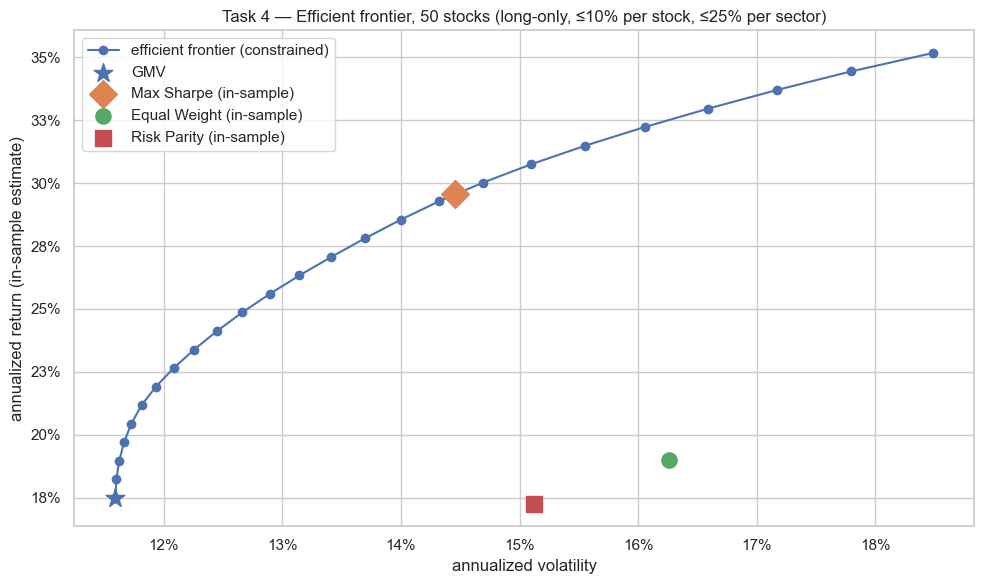

In [8]:
# 50 只: 最新市值最大
top50 = (panel[panel["date"] == panel["date"].max()]
         .nlargest(50, "mktcap")["ticker"].tolist())
sec50 = sectors.reindex(top50)
hist50 = monthly_ret[top50].dropna()

# 有效前沿 (in-sample)
ef = efficient_frontier(hist50, sec50, max_weight=0.10, sector_cap=0.25, n_points=25)
w_gmv = min_variance_weights(hist50, sec50, 0.10, 0.25)
w_ms = max_sharpe_weights(hist50, float(rf_m.mean()), sec50, 0.10, 0.25)

mu, cov = hist50.mean().to_numpy(), hist50.cov().to_numpy()
def pt(w):
    return (w @ mu) * 12, np.sqrt(w @ cov @ w) * np.sqrt(12)

# 约束验证 (quality check: constraints verified after optimization)
for name, w in [("GMV", w_gmv), ("MaxSharpe", w_ms)]:
    ws = pd.Series(w, index=top50)
    sec_sum = ws.groupby(sec50).sum()
    print(f"{name}: sum={w.sum():.6f} | max weight={w.max():.1%} (cap 10%) | "
          f"max sector={sec_sum.max():.1%} (cap 25%) | min={w.min():.2e} (long-only)")

# [Chart 5] 有效前沿
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ef["port_vol"] * np.sqrt(12), ef["port_return"] * 12, "o-", lw=1.5,
        label="efficient frontier (constrained)")
for name, w, mk in [("GMV", w_gmv, "*"), ("Max Sharpe (in-sample)", w_ms, "D")]:
    r_, v_ = pt(w)
    ax.scatter(v_, r_, marker=mk, s=200, zorder=5, label=name)
# EW / RP 全样本点 (同一 50 只)
for label, r in alloc.items():
    pass
w_ew50 = np.full(50, 1 / 50)
r_, v_ = pt(w_ew50)
ax.scatter(v_, r_, marker="o", s=120, zorder=5, label="Equal Weight (in-sample)")
vols50 = hist50.std().to_numpy()
w_rp50 = (1 / vols50) / (1 / vols50).sum()
r_, v_ = pt(w_rp50)
ax.scatter(v_, r_, marker="s", s=120, zorder=5, label="Risk Parity (in-sample)")
ax.set_xlabel("annualized volatility")
ax.set_ylabel("annualized return (in-sample estimate)")
ax.set_title("Task 4 — Efficient frontier, 50 stocks (long-only, ≤10% per stock, ≤25% per sector)")
ax.legend()
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(FIG / "fig5_efficient_frontier.png", dpi=130, bbox_inches="tight")
plt.show()

,ann_return,ann_vol,sharpe,max_drawdown,max_dd_duration_periods,turnover_ann
method,,,,,,
Equal Weight,16.9%,17.5%,0.98,-22.6%,18,69%
Risk Parity (inv-vol),14.6%,16.0%,0.94,-21.9%,22,106%
"MVO (max-Sharpe, rolling)",20.8%,17.7%,1.17,-20.3%,17,409%


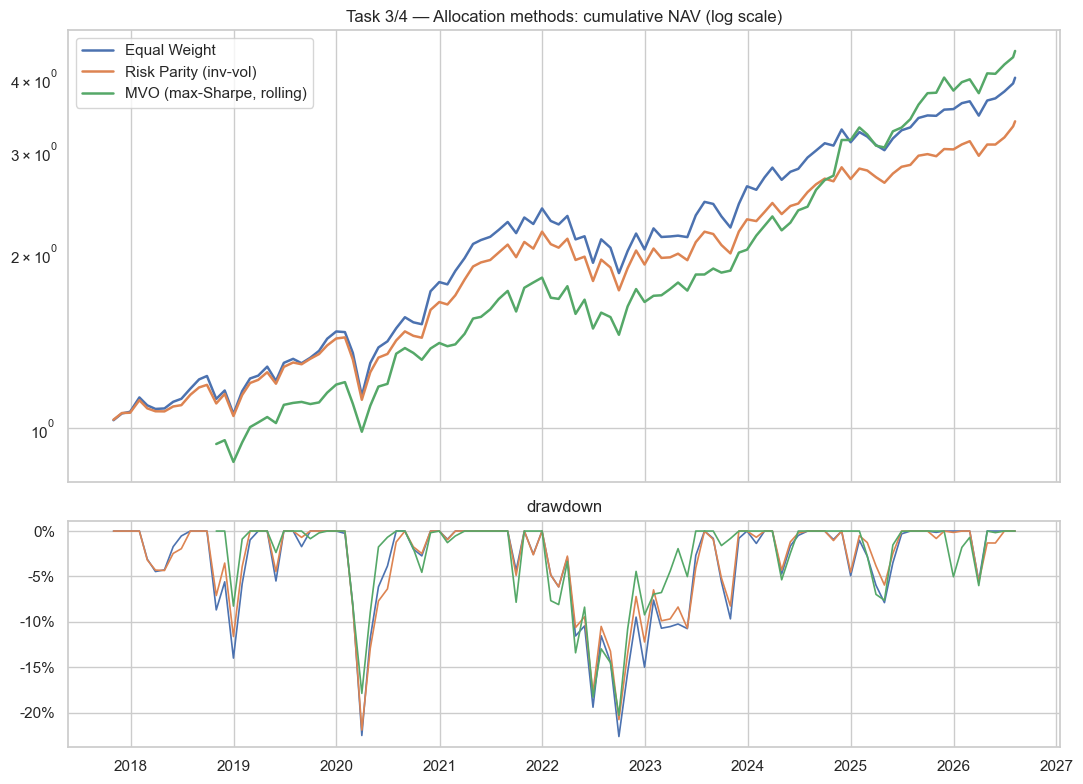

In [9]:
# 样本外滚动回测: MVO (24 个月回看) vs EW vs RP
alloc["MVO (max-Sharpe, rolling)"] = backtest_allocation(
    monthly_ret[top50], "mvo", lookback=24, sectors=sec50, rf_monthly=rf_m)

rows = []
for label, r in alloc.items():
    m = compute_risk_metrics(r["port_ret"], rf_m)
    rows.append({"method": label, "ann_return": m["ann_return"], "ann_vol": m["ann_vol"],
                 "sharpe": m["sharpe"], "max_drawdown": m["max_drawdown"],
                 "max_dd_duration_periods": m["max_dd_duration_periods"],
                 "turnover_ann": r["turnover"].mean() * 12})
cmp3 = pd.DataFrame(rows).set_index("method")
display(cmp3.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}", "sharpe": "{:.2f}",
                           "max_drawdown": "{:.1%}", "turnover_ann": "{:.0%}",
                           "max_dd_duration_periods": "{:.0f}"}))

# [Chart 4] 累计净值 + 回撤
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
for label, r in alloc.items():
    nav = (1 + r["port_ret"]).cumprod()
    axes[0].plot(nav.index, nav, lw=1.8, label=label)
    dd = nav / nav.cummax() - 1
    axes[1].plot(dd.index, dd, lw=1.2)
axes[0].set_yscale("log")
axes[0].set_title("Task 3/4 — Allocation methods: cumulative NAV (log scale)")
axes[0].legend()
axes[1].set_title("drawdown")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(FIG / "fig4_allocation_cumret.png", dpi=130, bbox_inches="tight")
plt.show()

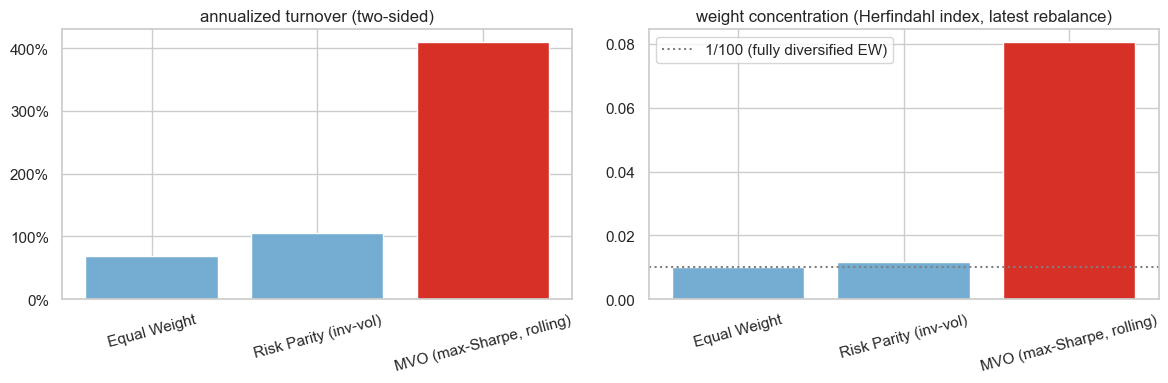

In [10]:
# [Chart 6] 换手率与权重集中度 (质量检查: turnover alongside performance)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cmp3.index, cmp3["turnover_ann"], color=["#74add1", "#74add1", "#d73027"])
axes[0].set_title("annualized turnover (two-sided)")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].tick_params(axis="x", rotation=15)

# 权重集中度: 最近一期权重的 Herfindahl 指数
hhi = {}
for label, r in alloc.items():
    w_last = r["weights"].iloc[:, -1].dropna()
    hhi[label] = (w_last ** 2).sum()
axes[1].bar(hhi.keys(), hhi.values(), color=["#74add1", "#74add1", "#d73027"])
axes[1].axhline(1 / 100, color="grey", ls=":", label="1/100 (fully diversified EW)")
axes[1].set_title("weight concentration (Herfindahl index, latest rebalance)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIG / "fig6_turnover_concentration.png", dpi=130, bbox_inches="tight")
plt.show()

## Task 5 — Why Simple Methods Often Beat Optimization

**Why 1/N and risk parity are hard to beat out of sample** (DeMiguel, Garlappi & Uppal 2009):

1. **Estimation error dominates.** Mean-variance weights are a levered function of μ̂ and Σ̂;
   with 24 monthly observations and 50 assets, μ̂ noise is amplified into extreme, unstable
   weights. EW has *zero* estimation error in expected returns; inverse-vol RP estimates
   only volatilities, which are an order of magnitude more stable than means.
2. **Turnover compounds the problem.** MVO re-estimates everything each month → large,
   noisy weight changes (see turnover chart); each trade pays costs without reliable
   expected gain. EW/RP trade mainly to rebalance drift and vol changes.
3. **Constraints are doing the real work.** Our MVO is long-only with 10%/25% caps — those
   constraints shrink the solution toward diversification and are the main reason the
   rolling MVO remains competitive at all. Unconstrained MVO on the same inputs would be
   far worse (concentrated in whatever had the best trailing Sharpe).
4. **Where optimization still earns its keep:** enforcing hard constraints (sectors,
   position limits), targeting a specific risk level, and handling many assets with
   structure (factor models for Σ̂, shrinkage for μ̂) — not in naive plug-in form.

**Reconciliation:** every number in the memo, the chart pack, and this notebook comes from
the same `src/risk.py` functions on the same data — tables and charts reconcile exactly.

## Conclusions & Limitations

- **Risk measurement is now standardized**: one function, one frequency, one rf treatment
  across quintile portfolios and allocation methods.
- **Diversification is real but bounded**: average correlation ≈ 0.3 → most idiosyncratic
  vol is gone by ~20–30 names; beyond that you hold market risk. Quintile betas vs SPY
  (0.86–1.37) confirm factor sorts also sort *market exposure*.
- **EW vs RP**: RP cuts vol and drawdown modestly at ~1.5× turnover; neither dominates on
  Sharpe over this sample.
- **MVO**: in-sample frontier looks great by construction; out of sample it remains
  competitive *only because constraints carry it* — at ~4× the turnover of RP. Treat
  in-sample μ̂ as descriptions, never forecasts.
- **Limitations**: survivorship bias (current constituents only); 100-name universe; no
  transaction costs; monthly frequency; RP uses the inverse-vol approximation rather than
  full ERC optimization (Maillard–Roncalli–Teiletche).